## **Subjectivity bias in digital media: a causal driver of virality or a reflection of popular content topics ?**

Authors: Benjamin Cerf, Céline Ferbach, Carla Lucas, Elyan Rougon, Chiara Tagiullo


### **1. Introduction**


##### 1.1. Setup

In [1]:
!pip install networkx
!pip install pgmpy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy as sp
import seaborn as sns
import networkx as nx
from pgmpy.base.DAG import DAG
from pathlib import Path

from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, roc_auc_score, log_loss, r2_score
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

from doubleml import DoubleMLData, DoubleMLIRM, DoubleMLPLR
from xgboost import XGBRegressor, XGBClassifier

SEED = 42
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

In [3]:
# load data
DATA_PATH = Path("data/OnlineNewsPopularity.csv")
df = pd.read_csv(DATA_PATH)

display(df.head(3))
display(df.tail(3))

# column cleanup
df.columns = df.columns.str.strip()

# check duplicates or missing
display(df.info())
print("Duplicate rows:", df.duplicated().sum())

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg,self_reference_min_shares,self_reference_max_shares,self_reference_avg_sharess,weekday_is_monday,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday,is_weekend,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,rate_negative_words,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,496.0,496.0,496.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500331,0.378279,0.040005,0.041263,0.040123,0.521617,0.092562,0.045662,0.013699,0.769231,0.230769,0.378636,0.100000,0.7,-0.350000,-0.600,-0.200000,0.5,-0.1875,0.0,0.1875,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.799756,0.050047,0.050096,0.050101,0.050001,0.341246,0.148948,0.043137,0.015686,0.733333,0.266667,0.286915,0.033333,0.7,-0.118750,-0.125,-0.100000,0.0,0.0000,0.5,0.0000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,918.0,918.0,918.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.217792,0.033334,0.033351,0.033334,0.682188,0.702222,0.323333,0.056872,0.009479,0.857143,0.142857,0.495833,0.100000,1.0,-0.466667,-0.800,-0.133333,0.0,0.0000,0.5,0.0000,1500


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg,self_reference_min_shares,self_reference_max_shares,self_reference_avg_sharess,weekday_is_monday,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday,is_weekend,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,rate_negative_words,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
39641,http://mashable.com/2014/12/27/son-pays-off-mo...,8.0,10.0,442.0,0.516355,1.0,0.644128,24.0,1.0,12.0,1.0,5.076923,8.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,691.0,168.25,6200.0,843300.0,295850.0,1753.882353,6880.687034,4206.439195,1400.0,1400.0,1400.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.159004,0.025025,0.025207,0.643794,0.146970,0.510296,0.024609,0.033937,0.024887,0.576923,0.423077,0.307273,0.136364,0.5,-0.356439,-0.8,-0.166667,0.454545,0.136364,0.045455,0.136364,1900
39642,http://mashable.com/2014/12/27/ukraine-blasts/,8.0,6.0,682.0,0.539493,1.0,0.692661,10.0,1.0,1.0,0.0,4.975073,5.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,-1.00,0.0,843300.0,254600.0,0.000000,3384.316871,1777.895883,452.0,452.0,452.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.040004,0.040003,0.839987,0.040002,0.040004,0.358578,-0.008066,0.020528,0.023460,0.466667,0.533333,0.236851,0.062500,0.5,-0.205246,-0.5,-0.012500,0.000000,0.000000,0.500000,0.000000,1100
39643,http://mashable.com/2014/12/27/youtube-channel...,8.0,10.0,157.0,0.701987,1.0,0.846154,1.0,1.0,0.0,2.0,4.471338,4.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.0,97.0,23.50,205600.0,843300.0,366200.0,3035.080555,3613.512953,3296.909481,2100.0,2100.0,2100.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.050001,0.799339,0.050000,0.050659,0.050001,0.517893,0.104892,0.063694,0.012739,0.833333,0.166667,0.247338,0.100000,0.5,-0.200000,-0.2,-0.200000,0.333333,0.250000,0.166667,0.250000,1300


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   url                            39644 non-null  object 
 1   timedelta                      39644 non-null  float64
 2   n_tokens_title                 39644 non-null  float64
 3   n_tokens_content               39644 non-null  float64
 4   n_unique_tokens                39644 non-null  float64
 5   n_non_stop_words               39644 non-null  float64
 6   n_non_stop_unique_tokens       39644 non-null  float64
 7   num_hrefs                      39644 non-null  float64
 8   num_self_hrefs                 39644 non-null  float64
 9   num_imgs                       39644 non-null  float64
 10  num_videos                     39644 non-null  float64
 11  average_token_length           39644 non-null  float64
 12  num_keywords                   39644 non-null 

None

Duplicate rows: 0


##### **1.2. PICO formulation**

We aim to investigate whether the subjectivity of an online news articles affects its popularity, measured by the number of times the article was shared on social media. Since subjectivity is not randomly assigned but determined by editorial and writing choices, this is a causal inference problem.

- Population: 39,644 online news articles published on [Mashable](https://mashable.com/), as recorded in the UCI Online News Popularity dataset available [here](https://archive.ics.uci.edu/dataset/332/online+news+popularity). Each observation corresponds to one article, described by content-based, sentiment-based, and metadata features.
  
- Intervention: the treatment variable is the subjectivity of the article. Subjectivity is measured by variables such as `global_subjectivity` or `title_subjectivity`, which range between 0 (fully objective) and 1 (fully subjective).

- Control: the control group consists of articles with lower subjectivity.
  
- Outcome: the outcome variable is the number of social media shares (`shares`), which measures article popularity. Due to the its highly skewed distribution, we consider Y=`log_shares`.


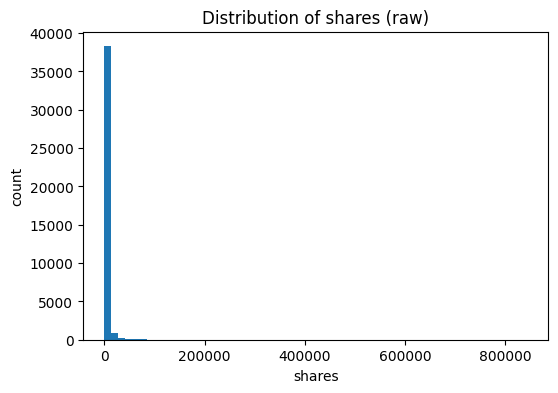

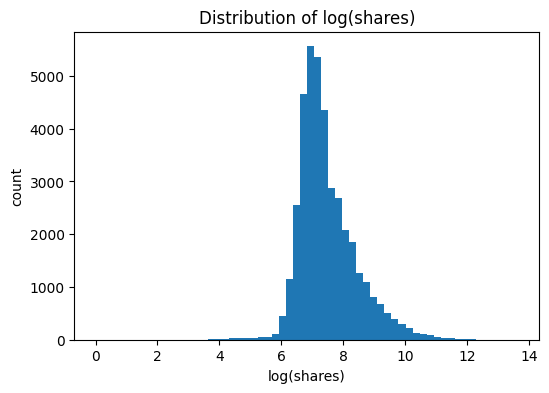

,count,mean,std,min,25%,50%,75%,max
shares,39644.0,3395.380184,11626.950749,1.0,946.000000,1400.000000,2800.000000,843300.000000
log_shares,39644.0,7.474855,0.930486,0.0,6.852243,7.244228,7.937375,13.645078


In [4]:
# outcome variable
y = "shares"

# outcome variable
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df[y], bins=60)
ax.set_title("Distribution of shares (raw)")
ax.set_xlabel("shares")
ax.set_ylabel("count")
plt.show()

# use log transform of shares, no share is 0
df["log_shares"] = np.log(df[y])

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["log_shares"], bins=60)
ax.set_title("Distribution of log(shares)")
ax.set_xlabel("log(shares)")
ax.set_ylabel("count")
plt.show()

display(df[[y, "log_shares"]].describe().T)

y = "log_shares"

### **2. Exploratory Data Analysis**
##### **2.1. Description**

,count,mean,std,min,25%,50%,75%,max
timedelta,39644.0,354.530471,214.163767,8.0,164.000000,339.000000,542.000000,731.000000
n_tokens_title,39644.0,10.398749,2.114037,2.0,9.000000,10.000000,12.000000,23.000000
n_tokens_content,39644.0,546.514731,471.107508,0.0,246.000000,409.000000,716.000000,8474.000000
n_unique_tokens,39644.0,0.548216,3.520708,0.0,0.470870,0.539226,0.608696,701.000000
n_non_stop_words,39644.0,0.996469,5.231231,0.0,1.000000,1.000000,1.000000,1042.000000
...,...,...,...,...,...,...,...,...
title_sentiment_polarity,39644.0,0.071425,0.265450,-1.0,0.000000,0.000000,0.150000,1.000000
abs_title_subjectivity,39644.0,0.341843,0.188791,0.0,0.166667,0.500000,0.500000,0.500000
abs_title_sentiment_polarity,39644.0,0.156064,0.226294,0.0,0.000000,0.000000,0.250000,1.000000
shares,39644.0,3395.380184,11626.950749,1.0,946.000000,1400.000000,2800.000000,843300.000000


Numeric columns: 60


,count,mean,std,min,25%,50%,75%,max
log_shares,39644.0,7.474855,0.930486,0.0,6.852243,7.244228,7.937375,13.645078
global_subjectivity,39644.0,0.443370,0.116685,0.0,0.396167,0.453457,0.508333,1.000000
title_subjectivity,39644.0,0.282353,0.324247,0.0,0.000000,0.150000,0.500000,1.000000


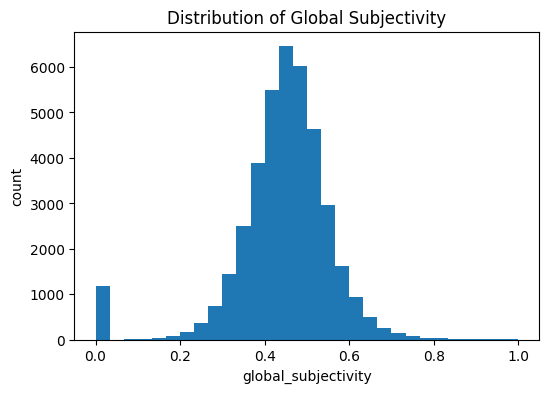

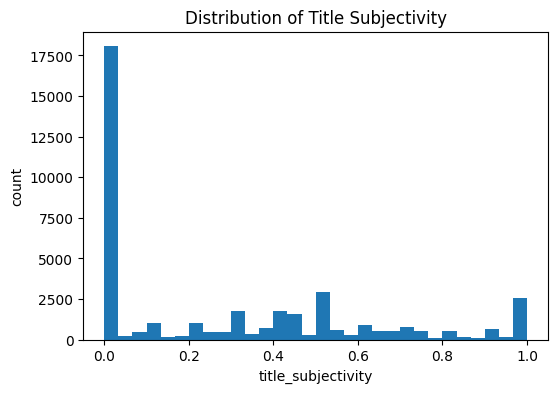

In [5]:
# we have categorical and numerical variables
# summary statistics for numeric columns
display(df.describe(include="number").T)

# keep a list of numeric feature columns (not url)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["log_shares"]]  # keep shares inside for some plots
print("Numeric columns:", len(num_cols))

# focus on key variables: y=log(shares) and subjectivity (+title_subjectivity)
key_vars = [y, "global_subjectivity", "title_subjectivity"]
key_vars = [c for c in key_vars if c in df.columns]

# summary statistics
display(df[key_vars].describe().T)

# Distribution of global subjectivity
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["global_subjectivity"], bins=30)
ax.set_title("Distribution of Global Subjectivity")
ax.set_xlabel("global_subjectivity")
ax.set_ylabel("count")
plt.show()

# and title
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["title_subjectivity"], bins=30)
ax.set_title("Distribution of Title Subjectivity")
ax.set_xlabel("title_subjectivity")
ax.set_ylabel("count")
plt.show()

# many are deemed perfectly objective

##### **2.2. Association**

,global_subjectivity,title_subjectivity,log_shares
global_subjectivity,1.000000,0.114123,0.075145
title_subjectivity,0.114123,1.000000,0.052714
log_shares,0.075145,0.052714,1.000000


Correlation between global_subjectivity and log_shares: 0.07514462643719119


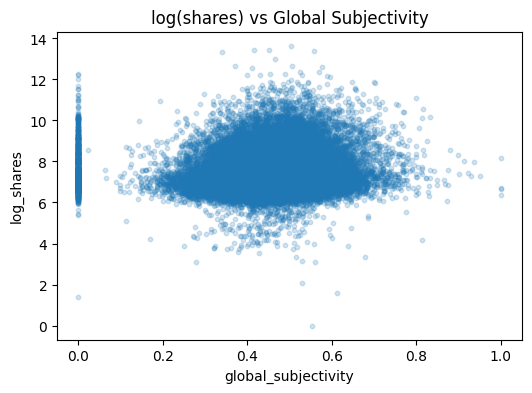

Median subjectivity: 0.4534573473025


high_subjectivity
0    7.381162
1    7.568548
Name: log_shares, dtype: float64

Difference in mean log_shares (High - Low): 0.1873855169756684


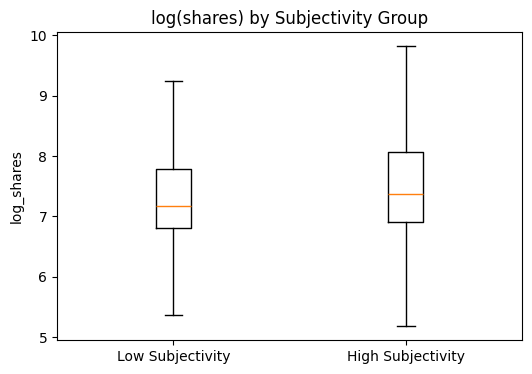

In [6]:
# correlation between subjectivity and y = shares
corr_matrix = df[["global_subjectivity", "title_subjectivity", y]].corr()
display(corr_matrix)

print("Correlation between global_subjectivity and log_shares:",
      corr_matrix.loc["global_subjectivity", y])

# scatter plot: global_subjectivity vs log_shares
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df["global_subjectivity"], df[y], 
           alpha=0.2, s=10)
ax.set_title("log(shares) vs Global Subjectivity")
ax.set_xlabel("global_subjectivity")
ax.set_ylabel("log_shares")
plt.show()

# define a simple treatment: High vs Low Subjectivity (median split)
median_subj = df["global_subjectivity"].median()
df["high_subjectivity"] = (df["global_subjectivity"] > median_subj).astype(int)
print("Median subjectivity:", median_subj)
# new categorical variable: high_subjectivity

# group comparison (mean outcome)
group_means = df.groupby("high_subjectivity")[y].mean()
display(group_means)

print("Difference in mean log_shares (High - Low):",
      group_means.loc[1] - group_means.loc[0])
# boxplot comparison

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(
    [df.loc[df["high_subjectivity"] == 0, y],
     df.loc[df["high_subjectivity"] == 1, y]],
    labels=["Low Subjectivity", "High Subjectivity"],
    showfliers=False
)
ax.set_title("log(shares) by Subjectivity Group")
ax.set_ylabel("log_shares")
plt.show()

##### **2.3. Visualization**

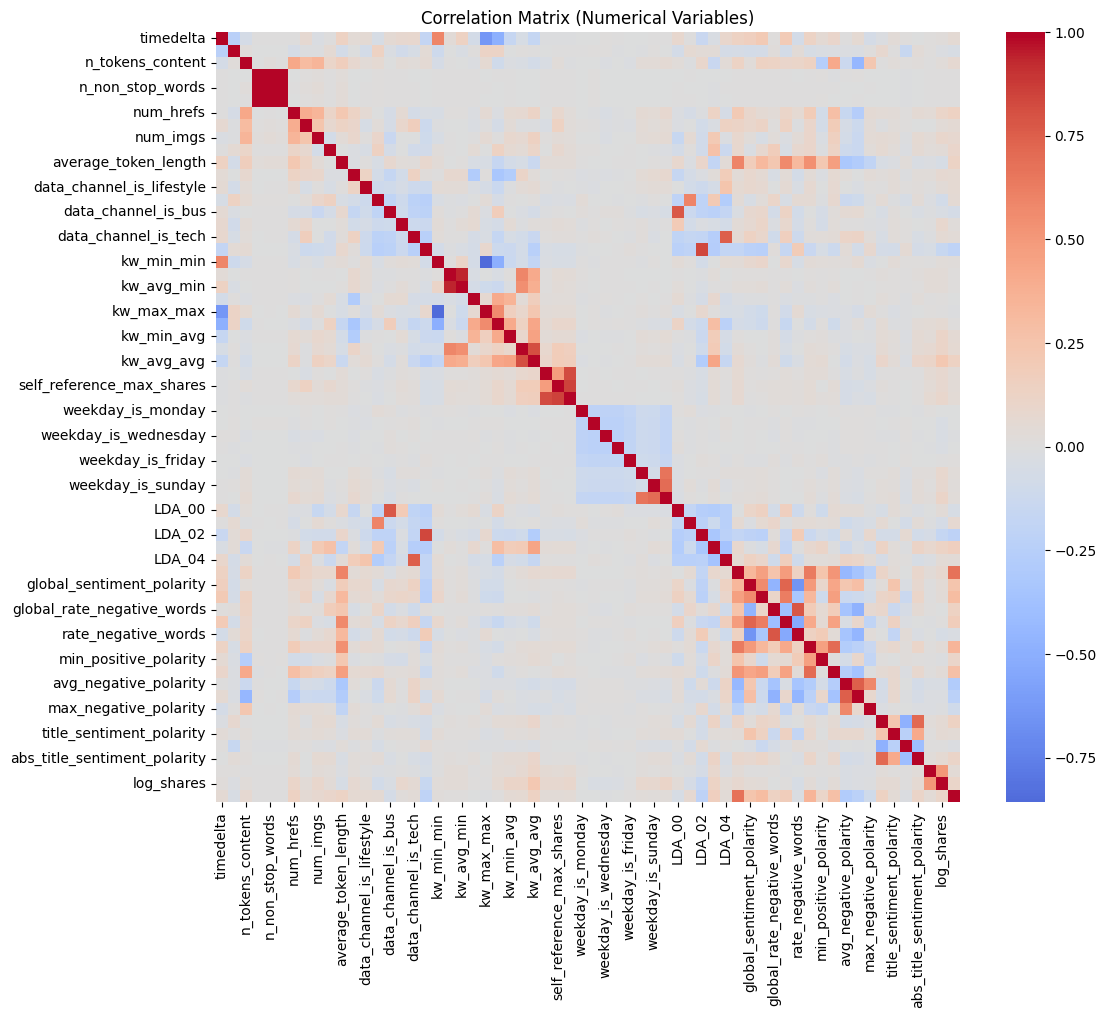

log_shares                    1.000000
shares                        0.509906
kw_avg_avg                    0.221720
LDA_03                        0.125962
is_weekend                    0.114387
kw_max_avg                    0.109292
kw_min_avg                    0.108823
num_hrefs                     0.105105
high_subjectivity             0.100694
num_imgs                      0.091518
self_reference_avg_sharess    0.087217
data_channel_is_socmed        0.081106
weekday_is_saturday           0.079147
self_reference_max_shares     0.077427
weekday_is_sunday             0.076975
Name: log_shares, dtype: float64

min_positive_polarity           -0.010767
max_negative_polarity           -0.014200
n_tokens_title                  -0.019030
min_negative_polarity           -0.022738
weekday_is_thursday             -0.028171
data_channel_is_bus             -0.030599
weekday_is_tuesday              -0.031073
avg_negative_polarity           -0.034310
weekday_is_wednesday            -0.036590
average_token_length            -0.045283
rate_negative_words             -0.048171
LDA_01                          -0.052993
data_channel_is_entertainment   -0.082504
data_channel_is_world           -0.151651
LDA_02                          -0.165034
Name: log_shares, dtype: float64

global_subjectivity           1.000000
high_subjectivity             0.679017
avg_positive_polarity         0.631749
average_token_length          0.597629
max_positive_polarity         0.518773
rate_positive_words           0.487481
global_rate_positive_words    0.467063
global_sentiment_polarity     0.339436
global_rate_negative_words    0.253181
min_positive_polarity         0.243984
Name: global_subjectivity, dtype: float64

kw_min_max              -0.018202
data_channel_is_bus     -0.028078
kw_max_max              -0.040859
n_tokens_title          -0.056804
kw_avg_max              -0.064106
LDA_02                  -0.178582
data_channel_is_world   -0.179194
max_negative_polarity   -0.223191
min_negative_polarity   -0.350070
avg_negative_polarity   -0.443187
Name: global_subjectivity, dtype: float64

In [7]:
# correlation matrix (numerical variables only)
corr_matrix = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            cmap="coolwarm",
            center=0,
            square=False,
            cbar=True)
plt.title("Correlation Matrix (Numerical Variables)")
plt.show()
# a bit dense

# some correlations with y = log_shares
target_corr = corr_matrix["log_shares"].sort_values(ascending=False)
display(target_corr.head(15))
display(target_corr.tail(15))

# with subjectivity
subj_corr = corr_matrix["global_subjectivity"].sort_values(ascending=False)
display(subj_corr.head(10))
display(subj_corr.tail(10))

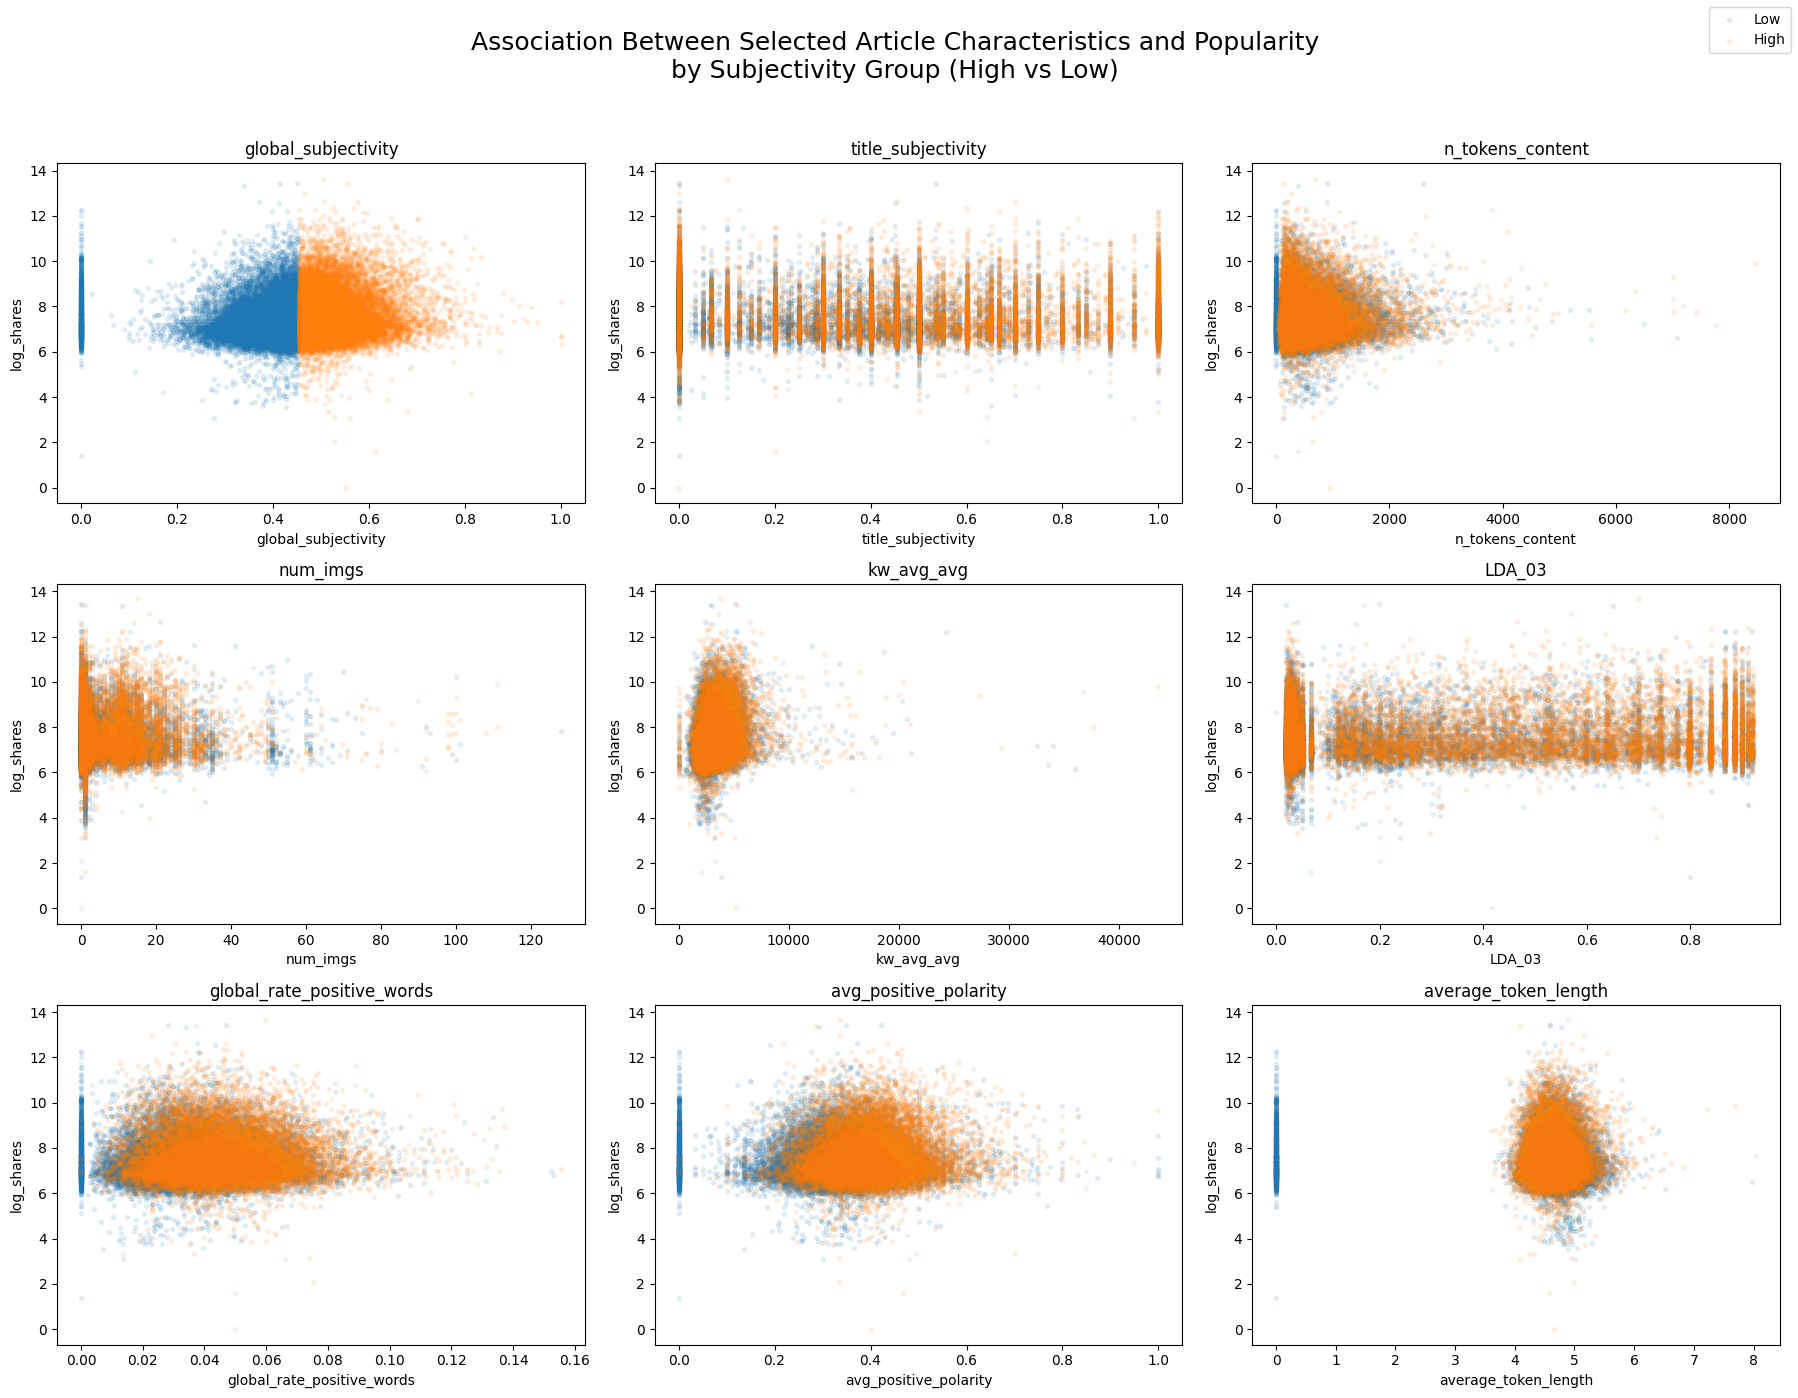

In [8]:
# scatter plots vs log(shares) colored by simple subjectivity treatment group
interesting_vars = [
    "global_subjectivity",
    "title_subjectivity",
    "n_tokens_content",
    "num_imgs",
    "kw_avg_avg",
    "LDA_03",
    "global_rate_positive_words",
    "avg_positive_polarity",
    "average_token_length"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, var in enumerate(interesting_vars):
    
    ax = axes[i]
    
    # Low subjectivity
    x_low = df.loc[df["high_subjectivity"] == 0, var]
    y_low = df.loc[df["high_subjectivity"] == 0, "log_shares"]
    
    ax.scatter(x_low, y_low, alpha=0.1, s=8, label="Low")
    
    # High subjectivity
    x_high = df.loc[df["high_subjectivity"] == 1, var]
    y_high = df.loc[df["high_subjectivity"] == 1, "log_shares"]
    
    ax.scatter(x_high, y_high, alpha=0.1, s=8, label="High")
    
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("log_shares")

# common title
fig.suptitle(
    "Association Between Selected Article Characteristics and Popularity\n"
    "by Subjectivity Group (High vs Low)",
    fontsize=18
)

# legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

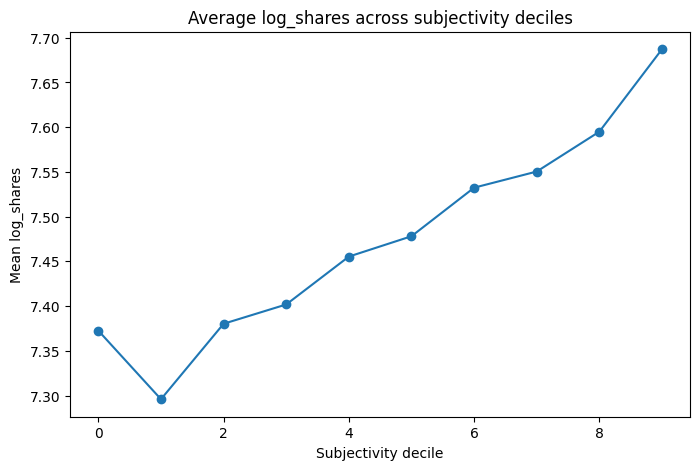

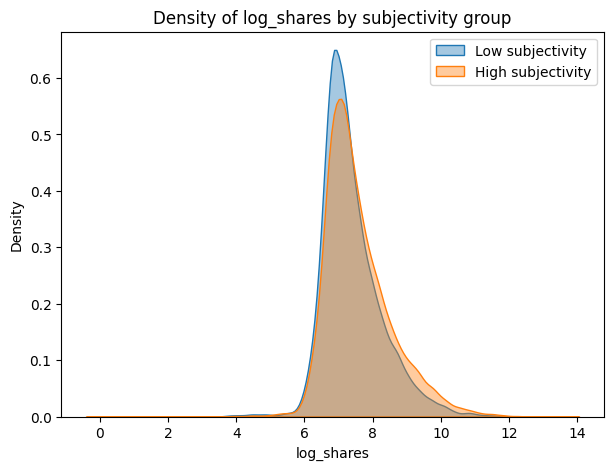

In [9]:
# binned plot: Subjectivity deciles vs mean log_shares
bins_volatiles = pd.qcut(df["global_subjectivity"], q=10, duplicates="drop")
bin_means = df.groupby(bins_volatiles)["log_shares"].mean()

plt.figure(figsize=(8, 5))
plt.plot(range(len(bin_means)), bin_means.values, marker="o")

plt.title("Average log_shares across subjectivity deciles")
plt.xlabel("Subjectivity decile")
plt.ylabel("Mean log_shares")
plt.show()

# densities
plt.figure(figsize=(7, 5))
sns.kdeplot(
    df.loc[df["high_subjectivity"] == 0, "log_shares"],
    label="Low subjectivity",
    fill=True,
    alpha=0.4
)
sns.kdeplot(
    df.loc[df["high_subjectivity"] == 1, "log_shares"],
    label="High subjectivity",
    fill=True,
    alpha=0.4
)
plt.title("Density of log_shares by subjectivity group")
plt.xlabel("log_shares")
plt.legend()
plt.show()

### **3. Identification with causal graph and choice of covariates to include**


##### **3.1. DAG**

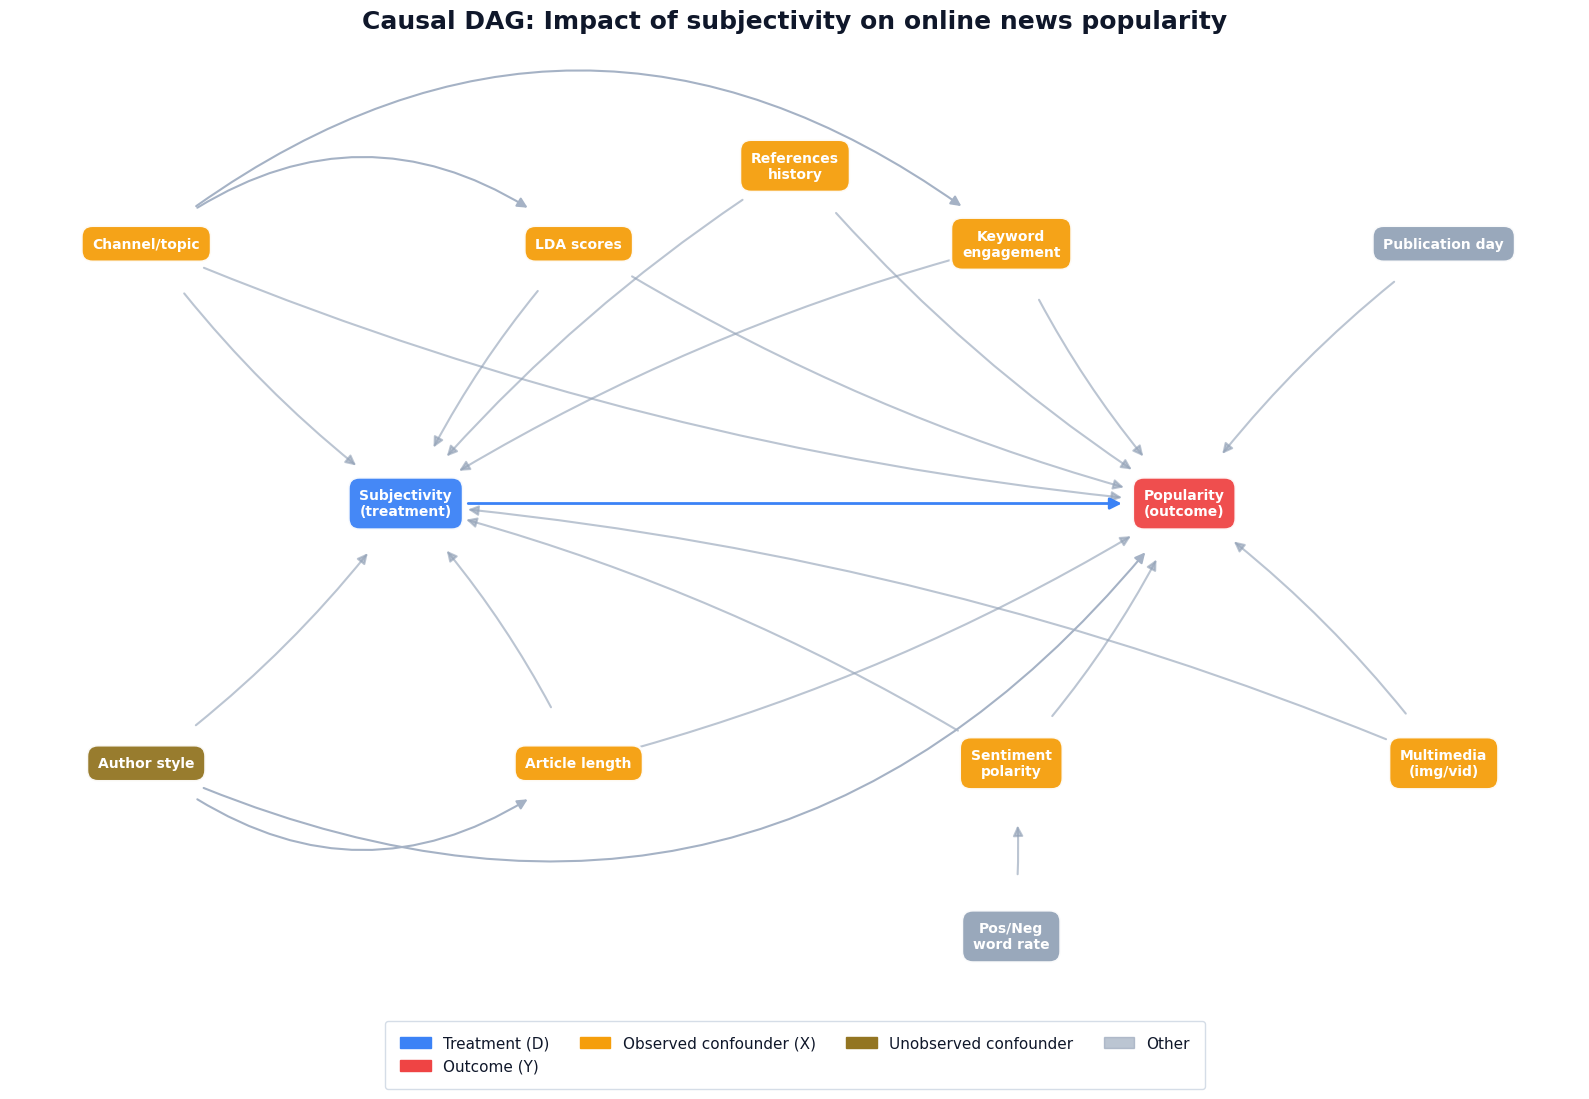

In [10]:
G = nx.DiGraph()

# 1. Nodes
nodes = {
    "Subjectivity":          "treatment",
    "Popularity":            "outcome",
    "Channel/Topic":         "confounder",
    "Keyword Engagement":    "confounder",
    "Article Length":        "confounder",
    "LDA scores" :           "confounder",
    "Multimedia (Img/Vid)":  "confounder",       
    "References History":    "confounder", 
    "Sentiment polarity":    "confounder",
    "Positive/Negative word rate": "other",
    "Publication Day":       "other",       
    "Author style":          "unobserved"           
}

G.add_nodes_from(nodes.keys())

# 2. Edges
main_edge = [("Subjectivity", "Popularity")]

outer_edges_top = [
    ("Channel/Topic", "Keyword Engagement"),
    ("Channel/Topic", "LDA scores")
]

outer_edges_bottom = [
    ("Author style", "Article Length"),
    ("Author style", "Popularity") 
]

standard_edges = [
    ("Author style", "Subjectivity"),
    ("Channel/Topic",       "Subjectivity"),
    ("Channel/Topic",       "Popularity"),
    ("LDA scores",          "Subjectivity"),
    ("LDA scores",          "Popularity"),
    ("Keyword Engagement",  "Subjectivity"),
    ("Keyword Engagement",  "Popularity"),
    ("Article Length",      "Subjectivity"),
    ("Article Length",      "Popularity"),
    ("Multimedia (Img/Vid)","Subjectivity"),
    ("Multimedia (Img/Vid)","Popularity"),
    ("References History",  "Popularity"), 
    ("References History",  "Subjectivity"),
    ("Publication Day",     "Popularity"), 
    ("Sentiment polarity",  "Subjectivity"),
    ("Sentiment polarity",  "Popularity"),
    ("Positive/Negative word rate", "Sentiment polarity") # Ajout de la flèche dé-commentée
]

G.add_edges_from(main_edge + outer_edges_top + outer_edges_bottom + standard_edges)

# 3. Grid for positions
pos = {
    "References History":      (5.25, 8.9),
    
    "Channel/Topic":           (1.5, 8.0),
    "LDA scores" :             (4.0, 8.0),
    "Keyword Engagement":      (6.5, 8.0),
    "Publication Day":         (9.0, 8.0),

    "Subjectivity":            (3.0, 5.0),
    "Popularity":              (7.5, 5.0),

    "Author style":            (1.5, 2.0),
    "Article Length":          (4.0, 2.0),
    "Sentiment polarity":      (6.5, 2.0),
    "Multimedia (Img/Vid)":    (9.0, 2.0),
    
    "Positive/Negative word rate": (6.5, 0.0)
}

# Labels 
display_labels = {
    "Subjectivity": "Subjectivity\n(treatment)",
    "Popularity": "Popularity\n(outcome)",
    "Channel/Topic": "Channel/topic",
    "Keyword Engagement": "Keyword\nengagement",
    "Article Length": "Article length",
    "LDA scores" : "LDA scores",
    "Multimedia (Img/Vid)": "Multimedia\n(img/vid)",
    "References History": "References\nhistory",
    "Publication Day": "Publication day",
    "Author style": "Author style",
    "Sentiment polarity": "Sentiment\npolarity",
    "Positive/Negative word rate": "Pos/Neg\nword rate"
}

# Colors
color_map = {
    "treatment":  "#3b82f6",  
    "outcome":    "#ef4444",  
    "confounder": "#f59e0b",  
    "unobserved": "#937522ff",  
    "other":      "#94a3b8"   
}

# 4. Graph display
fig, ax = plt.subplots(figsize=(16, 11)) 
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

margin = 45

# Standards
nx.draw_networkx_edges(G, pos, edgelist=standard_edges, ax=ax, edge_color="#94a3b8a1", 
                       width=1.5, arrows=True, arrowsize=15, connectionstyle="arc3,rad=0.08",
                       min_source_margin=margin, min_target_margin=margin)

# Outer edges 
nx.draw_networkx_edges(G, pos, edgelist=outer_edges_top, ax=ax, edge_color="#a5b2c5", 
                       width=1.5, arrows=True, arrowsize=15, connectionstyle="arc3,rad=-0.4",
                       min_source_margin=margin, min_target_margin=margin)
nx.draw_networkx_edges(G, pos, edgelist=outer_edges_bottom, ax=ax, edge_color="#a5b2c5", 
                       width=1.5, arrows=True, arrowsize=15, connectionstyle="arc3,rad=0.4",
                       min_source_margin=margin, min_target_margin=margin)

# Main causality
nx.draw_networkx_edges(G, pos, edgelist=main_edge, ax=ax, edge_color="#3b82f6", 
                       width=2, arrows=True, arrowsize=17,
                       min_source_margin=margin, min_target_margin=margin)

# Nodes
for node, (x, y) in pos.items():
    bbox_props = dict(boxstyle="round,pad=0.8", fc=color_map[nodes[node]], ec="white", lw=2, alpha=0.95)
    ax.text(x, y, display_labels[node], ha='center', va='center', 
            fontsize=10, fontweight='bold', color='white', bbox=bbox_props, zorder=5)

# Legend and title
legend_handles = [
    mpatches.Patch(color="#3b82f6", label="Treatment (D)"),
    mpatches.Patch(color="#ef4444", label="Outcome (Y)"),
    mpatches.Patch(color="#f59e0b", label="Observed confounder (X)"),
    mpatches.Patch(color="#937522ff", label="Unobserved confounder"), 
    mpatches.Patch(color="#94a3b8a1", label="Other")
]

ax.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=4,
          fontsize=11, facecolor="white", edgecolor="#cbd5e1", labelcolor="#0f172a", borderpad=1)

ax.set_title("Causal DAG: Impact of subjectivity on online news popularity",
             color="#0f172a", fontsize=18, fontweight="bold", pad=15)

ax.axis("off")
plt.tight_layout()
plt.show()

##### **3.2. Explanation of the Causal DAG**

To ensure a robust causal estimation, we mapped the Data Generating Process (DGP) of an online news article. Our DAG is structured around:

* **Outcome ($Y$) - Popularity:** The target variable, measured by `log_shares` to stabilize the highly skewed distribution of shares.
* **Treatment ($D$) - Subjectivity:** The main variable of interest (`high_subjectivity` or `global_subjectivity`).

**Observed confounders ($X$):**
* **Channel/topic:** Measured by categorical indicators (e.g., `data_channel_is_tech`). The editorial section dictates the writing style (subjectivity) and the sharing behavior.
* **LDA scores:** Measured by `LDA_00` through `LDA_04`. Latent Dirichlet Allocation (LDA) provides an algorithmic topic modeling. It captures the probability distribution of an article across 5 latent themes. Certain underlying themes naturally attract more subjective coverage and higher virality.
* **Keyword engagement:** Measured by historical keyword stats (e.g., `kw_avg_avg`, `kw_max_min`). Trending keywords attract both opinionated coverage and high-sharing audiences.
* **Article length:** Measured by `n_tokens_content` and `n_tokens_title`. Longer pieces allow for more in-depth, opinionated writing, thus influencing subjectivity, while also targeting a more engaged readership.
* **Multimedia:** Measured by `num_imgs` and `num_videos`. Highly visual articles tend to have less text (affecting how subjectivity is computed) and are more prone to social media sharing.
* **References history:** Measured by internal network variables (e.g., `self_reference_avg_shares`). Articles referencing past viral Mashable posts benefit from an internal network effect and are often written by established, opinionated authors.
* **Publication day:** Measured by `weekday_is_*` and `is_weekend`. Editorial decisions and reader browsing behaviors vary depending on the day of the week.

**Unobserved confounder ($U$):**
* **Author style:** A critical unobserved variable. The human journalist behind the article possesses a specific writing style, reputation, and intent. This latent factor acts as a root cause simultaneously influencing the article's length, its subjectivity, and its ultimate popularity.

---

##### **3.3. Choice of covariates and exclusions**

To estimate the Average Treatment Effect (ATE) of subjectivity on popularity, we must condition on the right set of covariates to block non-causal backdoor paths, while strictly avoiding data leakage.

**3.2.1. Included covariates (the control set $X$):**
We include all observed confounders defined in our DAG: **Channel/topic**, **LDA scores**, **Article length**, **Keyword engagement**, **Multimedia**, **References history**, and **Publication day**. 
*Note: While Channel/topic and LDA scores both measure content themes and might present some redundancy, this is not an issue for our causal estimation. Double Machine Learning (DML) techniques, combined with flexible learners like Random Forests or XGBoost, natively handle high-dimensionality and multicollinearity without requiring manual variable dropping.*

**3.2.2. Strictly excluded variables (preventing data leakage):**
A critical methodological step in our analysis was the strict exclusion of all **sentiment and polarity** features (e.g., `global_sentiment_polarity`, `rate_positive_words`, `avg_positive_polarity`). 

* **The causal rationale:** In the context of NLP-generated datasets, sentiment polarity and subjectivity are computed simultaneously by the same algorithmic parser using identical lexicons. Therefore, sentiment is not a pre-treatment confounder that "causes" subjectivity. Instead, both are simultaneous descendants of the unobserved author intent. 
* **The statistical rationale:** Including sentiment features introduces severe Data Leakage. Our preliminary testing showed that including them allowed the propensity score model ($m(X)$) to predict the treatment with a perfect ROC-AUC of 1.000. This perfectly violates the strict **Overlap (positivity) assumption** required for DML ($\epsilon < m_0(X) < 1-\epsilon$). Removing these variables restores the validity of the control group and ensures the causal estimate is unbiased.

In [11]:
# Choice of covariates
covariates = [
    "data_channel_is_lifestyle", "data_channel_is_entertainment", 
    "data_channel_is_bus", "data_channel_is_socmed", "data_channel_is_world",

    "n_tokens_content", "n_tokens_title",

    "num_imgs", "num_videos",

    "kw_avg_avg",

    "num_self_hrefs", "self_reference_avg_sharess",

    "LDA_00", "LDA_01", "LDA_02", "LDA_03",

    "weekday_is_monday", "weekday_is_tuesday", "weekday_is_wednesday", 
    "weekday_is_thursday", "weekday_is_friday", "is_weekend"
]

### **4. Discussion on the assumptions chosen for identification of the effect**


##### **Assumption 1 : unconfoundedness**
##### {𝑌 (1), 𝑌 (0)} ⫫ 𝐴 | X  
The treatment assignment should be as good as random given the covariates.  
Our covariates seem to capture most editorial decisions driving both subjectivity and popularity, but several unmeasured confounders could remain:  
- Journalist identity : some writers are systematically more subjective and more popular due to their personal following, which is not in the dataset
- Trending news events : breaking stories and hotly-debated new topics are written more subjectively and generate more shares, which isn't necessarily captured captured by channel or LDA
- Editorial promotion : Mashable may actively promote certain articles on their homepage, boosting shares independently of subjectivity.  

However, we cannot test this assumption from the data alone.

##### **Assumption 2 : overlap**
##### 0 < P(A=1 | X) < 1 for all values of X  
Every "type" (defined by covariates) of article should have a nonzero probability of being either highly subjective or not.  
Subjectivity is not mechanically determined by length or topic, but some channel/topic combinations might be almost exclusively objective (e.g. financial news) or almost exclusively subjective (e.g. opinion columns), creating near-zero overlap in those regions. Likewise, articles with strong sentiment polariy are very likely to be exclusively subjective.  
We can check this empirically by plotting the propensity score distribution for treated and control groups : if they overlap well, the assumption holds.

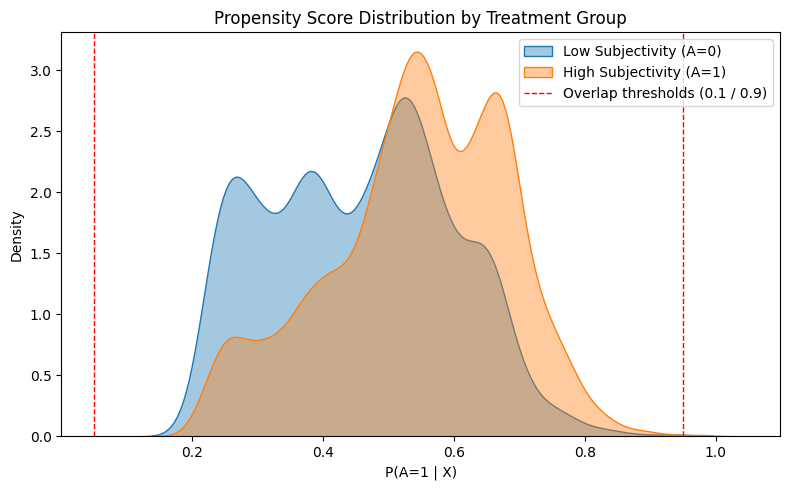

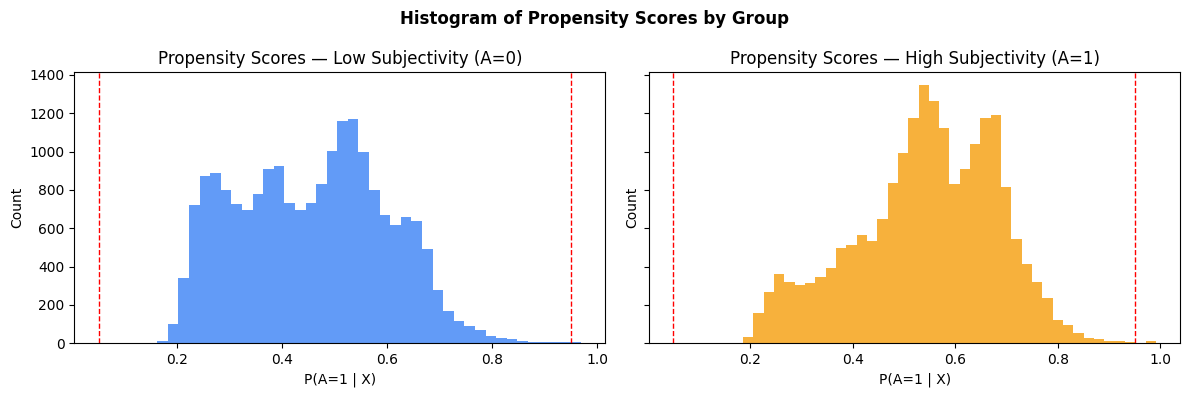

=== Propensity Score Summary ===
                     count   mean    std    min    25%    50%    75%    max
high_subjectivity                                                          
0                  19822.0  0.456  0.142  0.162  0.337  0.464  0.561  0.969
1                  19822.0  0.544  0.138  0.186  0.459  0.553  0.651  0.991

Articles with propensity score outside [0.05, 0.95]: 18 (= 0.05%)
→ Overlap is satisfied if this percentage is small.


In [12]:
A = "high_subjectivity"

X = df[covariates].copy()
a = df[A].values

# --- Estimate propensity score ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ps_model = LogisticRegression(max_iter=1000, random_state=SEED)
ps_model.fit(X_scaled, a)
propensity_scores = ps_model.predict_proba(X_scaled)[:, 1]
df["propensity_score"] = propensity_scores

# ── Plot 1: Overall propensity score distribution by treatment group ─────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(
    df.loc[df[A] == 0, "propensity_score"],
    label="Low Subjectivity (A=0)", fill=True, alpha=0.4, ax=ax
)
sns.kdeplot(
    df.loc[df[A] == 1, "propensity_score"],
    label="High Subjectivity (A=1)", fill=True, alpha=0.4, ax=ax
)
ax.axvline(0.05, color="red", linestyle="--", linewidth=1, label="Overlap thresholds (0.1 / 0.9)")
ax.axvline(0.95, color="red", linestyle="--", linewidth=1)
ax.set_title("Propensity Score Distribution by Treatment Group")
ax.set_xlabel("P(A=1 | X)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

# ── Plot 2: Histogram of propensity scores (check for mass near 0 or 1) ──────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, group, label in zip(axes, [0, 1], ["Low Subjectivity (A=0)", "High Subjectivity (A=1)"]):
    scores = df.loc[df[A] == group, "propensity_score"]
    ax.hist(scores, bins=40, color="#3b82f6" if group == 0 else "#f59e0b", alpha=0.8)
    ax.set_title(f"Propensity Scores — {label}")
    ax.set_xlabel("P(A=1 | X)")
    ax.set_ylabel("Count")
    ax.axvline(0.05, color="red", linestyle="--", linewidth=1)
    ax.axvline(0.95, color="red", linestyle="--", linewidth=1)
plt.suptitle("Histogram of Propensity Scores by Group", fontweight="bold")
plt.tight_layout()
plt.show()

# ── Numerical summary ─────────────────────────────────────────────────────────
print("=== Propensity Score Summary ===")
print(df.groupby(A)["propensity_score"].describe().round(3))

n_violated = ((propensity_scores < 0.05) | (propensity_scores > 0.95)).sum()
pct_violated = 100 * n_violated / len(df)
print(f"\nArticles with propensity score outside [0.05, 0.95]: {n_violated} (= {pct_violated:.2f}%)")
print("→ Overlap is satisfied if this percentage is small.")

The overlap assumption seems to be respected here.  

##### **Assumptions 3 and 4 : SUTVA  and Generalization**
 
- No interference: the subjectivity of one article does not affect the popularity of another article. This is debatable in the case where a highly subjective article goes viral and would crowd out shares for other articles published the following or previous days, but it seems coherent otherwise.
- Generalization : Training and test data are drawn from the same distribution.

### **5. Estimation with an appropriate causal estimator and cross-validation**
(double post lasso, double machine learning, generic machine learning, inverse propensity score, augmented propensity score) and regressor (lasso, ridge, random forest, boosting). It is not expected that you test or use every method.

##### **5.1. Model selection**


In [13]:
# Preparation before XGBoost and DML
df.columns = df.columns.str.replace(r'[\[\]<]', '_', regex=True)
df_clean = df.dropna(subset=['log_shares', 'high_subjectivity', 'global_subjectivity'] + covariates).copy()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier

print("==================================================")
print(" 6. MODEL SELECTION ")
print("==================================================")

# Data preparation
X = df_clean[covariates]
Y = df_clean['log_shares']
D_bin = df_clean['high_subjectivity']
D_cont = df_clean['global_subjectivity'] 

# CV 
cv_inner = KFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================================
# A. SELECTION FOR THE OUTCOME Y
# ==========================================================
print("\n--- Model selection : outcome model E[Y|X] ---")

models_Y = {
    "Lasso (linear)": (
        Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(random_state=42))]),
        {'lasso__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}
    ),
    "Random Forest": (
        RandomForestRegressor(random_state=42),
        {'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 7, None]}
    ),
    "XGBoost": (
        XGBRegressor(tree_method='hist', random_state=42),
        {'n_estimators': [50, 100, 200], 'max_depth': [3, 4, 5, 6], 'learning_rate': [0.01, 0.05, 0.1]}
    )
}

for name, (model, params) in models_Y.items():
    search = RandomizedSearchCV(model, params, n_iter=10, cv=cv_inner, 
                                scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
    search.fit(X, Y)
    print(f"{name:>15} -> Best RMSE with CV : {np.sqrt(-search.best_score_):.4f} (with {search.best_params_})")

# ==========================================================
# B. SELECTION FOR THE BINARY TREATMENT D_bin
# ==========================================================
print("\n--- Model selection : propensity model P(D_bin=1|X) ---")

models_D_bin = {
    "Lasso Logit": (
        Pipeline([('scaler', StandardScaler()), 
                  ('logit', LogisticRegression(penalty='l1', solver='liblinear', random_state=42))]),
        {'logit__C': [0.01, 0.1, 1.0, 10.0, 100.0]} 
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 7, None]}
    ),
    "XGBoost": (
        XGBClassifier(tree_method='hist', random_state=42),
        {'n_estimators': [50, 100, 200], 'max_depth': [3, 4, 5, 6], 'learning_rate': [0.01, 0.05, 0.1]}
    )
}

for name, (model, params) in models_D_bin.items():
    search = RandomizedSearchCV(model, params, n_iter=10, cv=cv_inner, 
                                scoring='roc_auc', random_state=42, n_jobs=-1)
    search.fit(X, D_bin)
    print(f"{name:>15} -> Best ROC-AUC with CV : {search.best_score_:.4f} (with {search.best_params_})")

# ==========================================================
# C. SELECTION FOR THE CONTINUOUS TREATMENT 
# ==========================================================
print("\n--- Model selection : continuous treatment E[D_cont|X] ---")

for name, (model, params) in models_Y.items():
    search = RandomizedSearchCV(model, params, n_iter=10, cv=cv_inner, 
                                scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
    search.fit(X, D_cont)
    print(f"{name:>15} -> Best RMSE with CV : {np.sqrt(-search.best_score_):.4f} (with {search.best_params_})")

##### **5.2. Model estimation**

In [ ]:
print("==================================================")
print(" HYBRID CAUSAL ESTIMATION : NESTED CROSS-VALIDATION")
print("==================================================")

# 1. Data for continuous treatment D_cont = global_subjectivity
dml_data_hybrid = DoubleMLData(df_clean, y_col='log_shares', d_cols='global_subjectivity', x_cols=covariates)

# 2. Models 
ml_l_hybrid = XGBRegressor(tree_method='hist', random_state=42, n_jobs=-1)     
ml_m_hybrid = RandomForestRegressor(random_state=42, n_jobs=-1)     

# 3. OUTER CROSS-VALIDATION
dml_plr_hybrid = DoubleMLPLR(dml_data_hybrid, ml_l=ml_l_hybrid, ml_m=ml_m_hybrid, 
                             n_folds=5, n_rep=3)

# 4. ROBUST GRID SEARCH
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1]
}

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10] 
}

par_grids_hybrid = {'ml_l': param_grid_xgb, 'ml_m': param_grid_rf}

# 5. INNER CROSS-VALIDATION 
print("Tuning hyperparameters (XGBoost + Random Forest) via Nested Grid Search CV...")
dml_plr_hybrid.tune(par_grids_hybrid, search_mode='grid_search', n_folds_tune=5)

# 6. FINAL TRAIN 
print("\nFitting the DML model...")
dml_plr_hybrid.fit(store_predictions=True)

# 7. RESULTS
print("\n--- CAUSAL RESULTS (Theta) ---")
print(dml_plr_hybrid.summary)

print("\n--- Hyperparameters ---")
print("Outcome Model E[Y|X] (XGBoost):", dml_plr_hybrid.params['ml_l'])
print("Treatment Model E[D|X] (Random Forest):", dml_plr_hybrid.params['ml_m'])


### **7. Develop and implement one of the following aspect (one choice among three):**
- Compare different statistical estimators or causal models for you estimates of the population effect. 
- Heterogeneous treatment effects: study the effect of the treatment on different subgroups of the population 
- Policy learning : What would be the best assignment policy ? Take inspiration from the doubleml case study.



### **8. Sensitivity analysis: placebo check, different covariate sets**



### **9. Conclusion and discussion of the results**
